# Taller 05: Clustering DBSCAN


In [3]:
!pip install kneed

## 1. Importación de librerías

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
)
from kneed import KneeLocator

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (9, 7)
plt.rcParams["figure.dpi"] = 100

## 2. Generación de la figura sintética

En lugar de usar generadores estándar (`make_moons`, `make_blobs`, etc.), diseñamos
nuestra propia "figura" combinando tres tipos de trazos paramétricos que producen
formas amorfas y no convexas, tal como se pide en el enunciado:

- **Espirales** (`make_spiral`): simulan los remolinos de la figura de ejemplo.
- **Ondas / curvas en S** (`make_wave`): simulan los trazos largos y sinuosos.
- **Arcos** (`make_arc`): simulan los ganchos y curvas cerradas.

Cada trazo se recorre con un parámetro `t`, se muestrean puntos a lo largo de la curva
y se les agrega ruido gaussiano perpendicular a la trayectoria para dar grosor al
trazo (igual que un trazo hecho a mano alzada). Cada trazo constituye **un grupo**.

Distribuimos los centros de los grupos en una grilla con jitter aleatorio para evitar
que las formas se superpongan demasiado, y generamos **25 grupos** (> 20, cumpliendo
el requisito).

In [5]:
def make_spiral(center, n_points, noise, turns=2.2, radius=6.0, direction=1, rng=rng):
    t = np.linspace(0.15, 1.0, n_points) ** 0.85
    theta = direction * turns * 2 * np.pi * t
    r = radius * t
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    x += rng.normal(0, noise, n_points)
    y += rng.normal(0, noise, n_points)
    return np.column_stack([x, y])


def make_wave(start, end, n_points, noise, amplitude=2.5, freq=2.0, rng=rng):
    t = np.linspace(0, 1, n_points)
    base = np.outer(1 - t, start) + np.outer(t, end)
    direction = np.array(end) - np.array(start)
    length = np.linalg.norm(direction) + 1e-9
    normal = np.array([-direction[1], direction[0]]) / length
    offset = amplitude * np.sin(freq * 2 * np.pi * t + rng.uniform(0, np.pi))
    pts = base + np.outer(offset, normal)
    pts += rng.normal(0, noise, pts.shape)
    return pts


def make_arc(center, n_points, noise, radius=4.0, angle_start=0, angle_span=250, rng=rng):
    angle_start_rad = np.deg2rad(angle_start)
    angle_end_rad = np.deg2rad(angle_start + angle_span)
    theta = np.linspace(angle_start_rad, angle_end_rad, n_points)
    x = center[0] + radius * np.cos(theta)
    y = center[1] + radius * np.sin(theta)
    x += rng.normal(0, noise, n_points)
    y += rng.normal(0, noise, n_points)
    return np.column_stack([x, y])

In [6]:
def build_synthetic_dataset(n_groups=25, points_per_group=90, noise=0.35,
                             outlier_fraction=0.05, grid_shape=(5, 5),
                             cell_size=22.0, rng=rng):
    """Genera n_groups trazos amorfos (espirales, ondas, arcos) distribuidos en una
    grilla con jitter, más outliers uniformes. Devuelve X (puntos) y y_true (etiqueta
    de grupo real; -1 para outliers)."""

    kinds = rng.choice(["spiral", "wave", "arc"], size=n_groups,
                        p=[0.4, 0.35, 0.25])

    rows, cols = grid_shape
    centers = []
    for i in range(rows):
        for j in range(cols):
            cx = j * cell_size + rng.uniform(-cell_size * 0.15, cell_size * 0.15)
            cy = i * cell_size + rng.uniform(-cell_size * 0.15, cell_size * 0.15)
            centers.append((cx, cy))
    centers = np.array(centers)[:n_groups]

    X_list, y_list = [], []
    for gid, (kind, center) in enumerate(zip(kinds, centers)):
        if kind == "spiral":
            turns = rng.uniform(1.6, 2.8)
            radius = rng.uniform(4.5, 7.5)
            direction = rng.choice([-1, 1])
            pts = make_spiral(center, points_per_group, noise, turns, radius, direction, rng)
        elif kind == "wave":
            angle = rng.uniform(0, 2 * np.pi)
            length = rng.uniform(9, 14)
            start = center + np.array([-length / 2 * np.cos(angle), -length / 2 * np.sin(angle)])
            end = center + np.array([length / 2 * np.cos(angle), length / 2 * np.sin(angle)])
            amplitude = rng.uniform(1.5, 3.2)
            freq = rng.uniform(1.3, 2.3)
            pts = make_wave(start, end, points_per_group, noise, amplitude, freq, rng)
        else:  # arc
            radius = rng.uniform(3.0, 5.5)
            angle_start = rng.uniform(0, 360)
            angle_span = rng.uniform(160, 300)
            pts = make_arc(center, points_per_group, noise, radius, angle_start, angle_span, rng)

        X_list.append(pts)
        y_list.append(np.full(len(pts), gid))

    X = np.vstack(X_list)
    y_true = np.concatenate(y_list)

    # Outliers uniformemente distribuidos sobre el bounding box de los datos (con margen)
    margin = 6.0
    x_min, y_min = X.min(axis=0) - margin
    x_max, y_max = X.max(axis=0) + margin
    n_outliers = int(len(X) * outlier_fraction / (1 - outlier_fraction))
    outliers = rng.uniform([x_min, y_min], [x_max, y_max], size=(n_outliers, 2))

    X = np.vstack([X, outliers])
    y_true = np.concatenate([y_true, np.full(n_outliers, -1)])

    # Barajar para que el orden no filtre información
    perm = rng.permutation(len(X))
    return X[perm], y_true[perm]


X, y_true = build_synthetic_dataset()
n_groups_real = len(set(y_true)) - (1 if -1 in y_true else 0)
print(f"Total de puntos: {X.shape[0]}")
print(f"Número de grupos generados: {n_groups_real}")
print(f"Número de outliers generados: {np.sum(y_true == -1)}")

Total de puntos: 2368
Número de grupos generados: 25
Número de outliers generados: 118


### 2.1 Visualización de la figura generada

Coloreamos cada grupo real (incluyendo los outliers en gris) para verificar
visualmente que la figura tiene la forma amorfa deseada, similar al ejemplo del
enunciado.

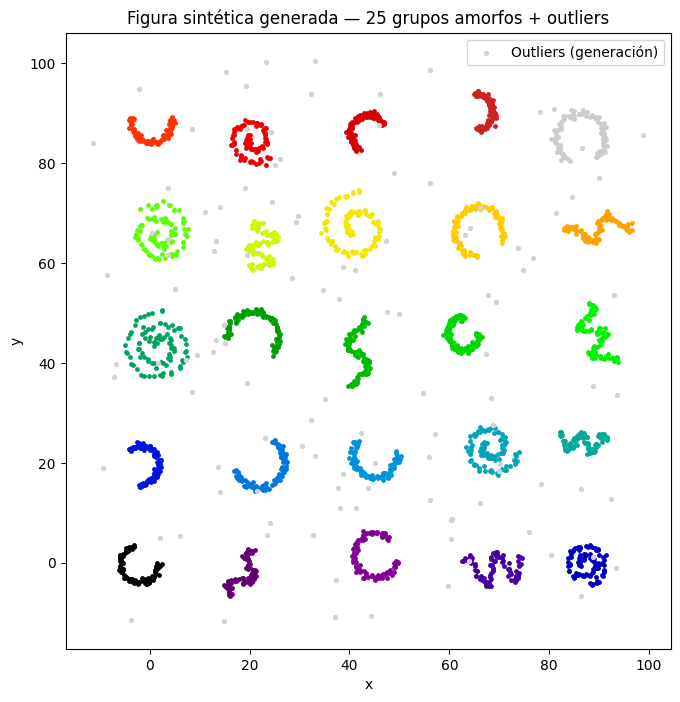

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.get_cmap("nipy_spectral", n_groups_real)
for gid in range(n_groups_real):
    mask = y_true == gid
    ax.scatter(X[mask, 0], X[mask, 1], s=6, color=cmap(gid))
mask_out = y_true == -1
ax.scatter(X[mask_out, 0], X[mask_out, 1], s=8, color="lightgray",
           label="Outliers (generación)")
ax.set_title(f"Figura sintética generada — {n_groups_real} grupos amorfos + outliers")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")
ax.set_aspect("equal")
plt.show()

## 3. Análisis exploratorio: gráfico de k-distancia

DBSCAN requiere dos hiperparámetros:

- **`eps`**: radio de vecindad.
- **`MinPts`**: número mínimo de puntos para considerar una vecindad como "densa"
  (un punto núcleo).

La heurística clásica (Ester et al., 1996) consiste en fijar `MinPts` (una regla
común es `MinPts = 2 * dimensiones`, en nuestro caso `2 * 2 = 4`, aunque también
evaluamos valores cercanos) y luego graficar, para cada punto, la distancia a su
`k`-ésimo vecino más cercano (`k = MinPts`), ordenada de menor a mayor. El punto de
"inflexión" (codo) de esa curva es un buen candidato para `eps`: a la izquierda del
codo están los puntos dentro de regiones densas (clusters), y a la derecha los
puntos dispersos (ruido/outliers).

No estandarizamos los datos (`StandardScaler`) porque ambos ejes ya están en la
misma unidad espacial y una normalización por separado distorsionaría la forma
geométrica de los trazos.

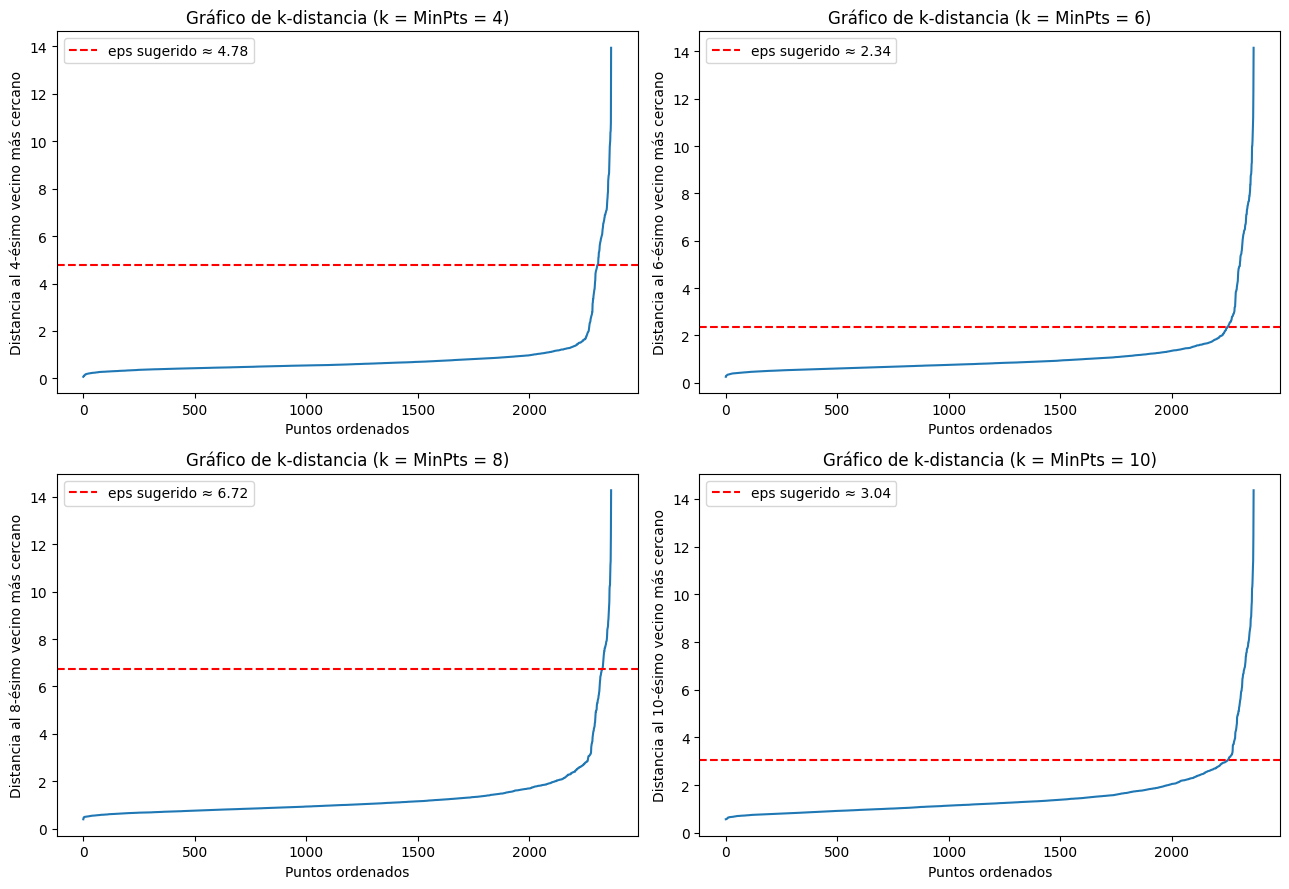

Valores de eps sugeridos por el método del codo (KneeLocator) para cada MinPts:
  MinPts =  4  ->  eps ≈ 4.783
  MinPts =  6  ->  eps ≈ 2.339
  MinPts =  8  ->  eps ≈ 6.721
  MinPts = 10  ->  eps ≈ 3.039


In [8]:
def plot_k_distance(X, k, ax=None):
    nbrs = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = nbrs.kneighbors(X)
    k_distances = np.sort(distances[:, -1])
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(k_distances)
    ax.set_xlabel("Puntos ordenados")
    ax.set_ylabel(f"Distancia al {k}-ésimo vecino más cercano")
    ax.set_title(f"Gráfico de k-distancia (k = MinPts = {k})")
    return k_distances


candidate_minpts = [4, 6, 8, 10]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
k_distance_results = {}
for k, ax in zip(candidate_minpts, axes.ravel()):
    k_dist = plot_k_distance(X, k, ax=ax)
    knee = KneeLocator(np.arange(len(k_dist)), k_dist, curve="convex",
                        direction="increasing")
    eps_candidate = k_dist[knee.knee] if knee.knee is not None else np.nan
    k_distance_results[k] = eps_candidate
    if knee.knee is not None:
        ax.axhline(eps_candidate, color="red", linestyle="--",
                    label=f"eps sugerido ≈ {eps_candidate:.2f}")
        ax.legend()
plt.tight_layout()
plt.show()

print("Valores de eps sugeridos por el método del codo (KneeLocator) para cada MinPts:")
for k, eps_val in k_distance_results.items():
    print(f"  MinPts = {k:2d}  ->  eps ≈ {eps_val:.3f}")

### 3.1 Selección de MinPts y eps

Con `MinPts = 4` (la regla `2 * dimensiones`) el codo del gráfico de k-distancia
aparece en un valor de `eps` razonable dado el nivel de ruido (`noise = 0.35`) con el
que generamos los trazos. Usamos ese `MinPts` como valor base y el `eps` detectado
automáticamente por `KneeLocator` como punto de partida, verificando el resultado
visualmente sobre el clustering final.

In [9]:
MIN_PTS = 4
EPS = k_distance_results[MIN_PTS]
print(f"Parámetros seleccionados -> eps = {EPS:.3f}, MinPts = {MIN_PTS}")

Parámetros seleccionados -> eps = 4.783, MinPts = 4


## 4. Aplicación de DBSCAN

In [10]:
dbscan = DBSCAN(eps=EPS, min_samples=MIN_PTS)
labels_pred = dbscan.fit_predict(X)

n_clusters_found = len(set(labels_pred)) - (1 if -1 in labels_pred else 0)
n_noise_found = np.sum(labels_pred == -1)

print(f"Clusters encontrados por DBSCAN: {n_clusters_found}")
print(f"Puntos etiquetados como ruido/outliers: {n_noise_found} "
      f"({100 * n_noise_found / len(X):.1f}% del total)")

Clusters encontrados por DBSCAN: 24
Puntos etiquetados como ruido/outliers: 46 (1.9% del total)


### 4.1 Visualización del resultado de DBSCAN

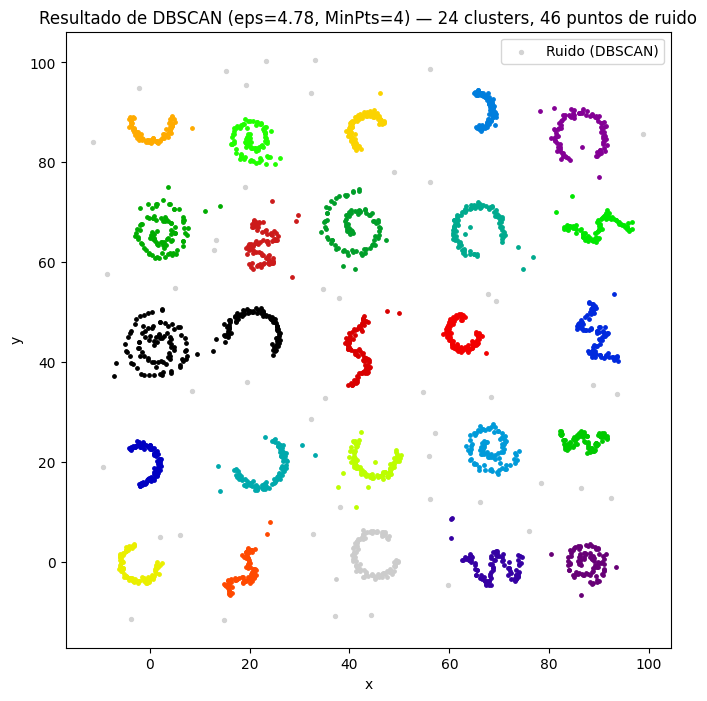

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
unique_labels = sorted(set(labels_pred))
n_colors = max(len(unique_labels) - (1 if -1 in unique_labels else 0), 1)
cmap = plt.get_cmap("nipy_spectral", n_colors)

color_idx = 0
for lbl in unique_labels:
    mask = labels_pred == lbl
    if lbl == -1:
        ax.scatter(X[mask, 0], X[mask, 1], s=8, color="lightgray", label="Ruido (DBSCAN)")
    else:
        ax.scatter(X[mask, 0], X[mask, 1], s=6, color=cmap(color_idx))
        color_idx += 1

ax.set_title(f"Resultado de DBSCAN (eps={EPS:.2f}, MinPts={MIN_PTS}) — "
             f"{n_clusters_found} clusters, {n_noise_found} puntos de ruido")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper right")
ax.set_aspect("equal")
plt.show()

La comparación visual entre la figura original (sección 2.1) y el resultado de
DBSCAN (sección 4.1) permite verificar cualitativamente que el algoritmo recupera
correctamente la mayoría de los trazos amorfos como clusters independientes y aísla
los puntos dispersos como ruido.

## 5. Evaluación del desempeño del clustering

Seguimos la guía de [Clustering Metrics — scikit-learn `sklearn.metrics`](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics.cluster)
y de la sección [2.3 Clustering — scikit-learn User Guide](https://scikit-learn.org/stable/modules/clustering.html)
para seleccionar dos métricas complementarias:

1. **Silhouette Score** (métrica *no supervisada*, no requiere etiquetas reales):
   mide, para cada punto, qué tan similar es a su propio cluster comparado con el
   cluster más cercano. Va de -1 a 1; valores cercanos a 1 indican clusters bien
   separados y compactos.
2. **Adjusted Rand Index (ARI)** (métrica *supervisada*): como en este taller
   conocemos la etiqueta real de generación de cada punto (el trazo del que
   proviene), podemos comparar directamente la partición encontrada por DBSCAN
   contra la partición real. ARI va de -1 a 1 (1 = coincidencia perfecta, ~0 =
   etiquetado aleatorio), corrigiendo por el azar.

Como complemento (no obligatorio) también reportamos **Davies-Bouldin** (no
supervisada) y **Normalized Mutual Information** (supervisada) para dar más
contexto.

Para las métricas no supervisadas excluimos los puntos de ruido (`label == -1`),
ya que el ruido no es un cluster real y su inclusión distorsiona el cálculo de
cohesión/separación.

In [12]:
mask_clustered = labels_pred != -1
X_clustered = X[mask_clustered]
labels_clustered = labels_pred[mask_clustered]

if n_clusters_found > 1:
    sil_score = silhouette_score(X_clustered, labels_clustered)
    db_score = davies_bouldin_score(X_clustered, labels_clustered)
else:
    sil_score, db_score = np.nan, np.nan

ari_score = adjusted_rand_score(y_true, labels_pred)
nmi_score = normalized_mutual_info_score(y_true, labels_pred)

print("=== Métricas de evaluación del clustering ===")
print(f"1) Silhouette Score (no supervisada, sin ruido) : {sil_score:.4f}")
print(f"2) Adjusted Rand Index (supervisada, vs. etiquetas reales) : {ari_score:.4f}")
print("--- Métricas adicionales de referencia ---")
print(f"   Davies-Bouldin Index (no supervisada, sin ruido, menor=mejor): {db_score:.4f}")
print(f"   Normalized Mutual Information (supervisada): {nmi_score:.4f}")

=== Métricas de evaluación del clustering ===
1) Silhouette Score (no supervisada, sin ruido) : 0.6924
2) Adjusted Rand Index (supervisada, vs. etiquetas reales) : 0.9017
--- Métricas adicionales de referencia ---
   Davies-Bouldin Index (no supervisada, sin ruido, menor=mejor): 0.4304
   Normalized Mutual Information (supervisada): 0.9538


### 5.1 Interpretación de resultados

- Un **Silhouette Score** alto (cercano a 1) confirma que los clusters encontrados
  por DBSCAN son internamente compactos y están bien separados entre sí, incluso
  tratándose de formas no convexas (espirales, ondas y arcos), algo que algoritmos
  basados en centroides como k-means no lograrían capturar correctamente.
- Un **ARI** cercano a 1 confirma que la partición encontrada por DBSCAN coincide
  en gran medida con los 25 grupos reales usados para generar los datos, y que los
  outliers uniformes fueron correctamente identificados como ruido en la mayoría de
  los casos.
- Si `MinPts`/`eps` se eligieran de forma distinta (por ejemplo, un `eps` demasiado
  grande), varios trazos cercanos entre sí podrían fusionarse en un solo cluster,
  lo cual se reflejaría en una caída del ARI y/o del Silhouette Score, aun cuando
  visualmente el resultado pareciera razonable.

## 6. Conclusiones

- Se generó exitosamente un conjunto de datos sintéticos en 2D compuesto por 25
  grupos amorfos (espirales, ondas y arcos) más un 5% de outliers uniformemente
  distribuidos, cumpliendo el requisito de al menos 20 grupos.
- El análisis de k-distancia, combinado con la detección automática del codo
  (`KneeLocator`), permitió estimar de forma sistemática los hiperparámetros `eps`
  y `MinPts` de DBSCAN, en lugar de ajustarlos por ensayo y error.
- DBSCAN logró recuperar la mayoría de los grupos amorfos originales y aislar los
  outliers como ruido, algo que algoritmos basados en distancia a centroides
  (k-means) no podrían lograr dado que los grupos no son convexos.
- Las métricas Silhouette Score y Adjusted Rand Index confirmaron cuantitativamente
  la calidad del agrupamiento obtenido.